# Result Analysis

En este apartado analizaremos los resultados de los experimentos.

In [1]:
import pandas as pd
import numpy as np

# 1. Definimos los datos manualmente basándonos en tu mensaje
# Usamos 'None' para los experimentos que aún no tienen resultados
data = [
    {"ID Exp.": "EXP-CNN-01",    "Acc. Medio": 0.7011, "IC Inf (95%)": 0.6100, "IC Sup (95%)": 0.7900},
    {"ID Exp.": "EXP-CNN-02",    "Acc. Medio": 0.7298, "IC Inf (95%)": 0.6400, "IC Sup (95%)": 0.8100},
    {"ID Exp.": "EXP-CNN-03",    "Acc. Medio": 0.9701, "IC Inf (95%)": 0.9450, "IC Sup (95%)": 0.9900},
    {"ID Exp.": "EXP-CNN-04",    "Acc. Medio": 0.9200, "IC Inf (95%)": 0.8800, "IC Sup (95%)": 0.9550},
    {"ID Exp.": "EXP-CNN-05",    "Acc. Medio": None,   "IC Inf (95%)": None,   "IC Sup (95%)": None},
    {"ID Exp.": "EXP-LSTM-01",   "Acc. Medio": 0.7609,   "IC Inf (95%)": 0.6800,   "IC Sup (95%)": 0.8400},
    {"ID Exp.": "EXP-LSTM-02",   "Acc. Medio": 0.8296,   "IC Inf (95%)": 0.7500,   "IC Sup (95%)": 0.9000},
    {"ID Exp.": "EXP-LSTM-03",   "Acc. Medio": 0.9050,   "IC Inf (95%)": 0.8650,   "IC Sup (95%)": 0.9450},
    {"ID Exp.": "EXP-LSTM-04",   "Acc. Medio": 0.9799,   "IC Inf (95%)": 0.9600,   "IC Sup (95%)": 0.9950},
    {"ID Exp.": "EXP-Bi-LSTM-01","Acc. Medio": 0.8402,   "IC Inf (95%)": 0.7600,   "IC Sup (95%)": 0.9100},
    {"ID Exp.": "EXP-Bi-LSTM-02","Acc. Medio": 0.9300,   "IC Inf (95%)": 0.8800,   "IC Sup (95%)": 0.9800},
    {"ID Exp.": "EXP-Bi-LSTM-03","Acc. Medio": 0.8652,   "IC Inf (95%)": 0.8150,   "IC Sup (95%)": 0.9100},
    {"ID Exp.": "EXP-Bi-LSTM-04","Acc. Medio": 0.9751,   "IC Inf (95%)": 0.9500,   "IC Sup (95%)": 0.9950},
    {"ID Exp.": "EXP-ST-GCN-01", "Acc. Medio": 0.8300, "IC Inf (95%)": 0.7500, "IC Sup (95%)": 0.9000},
    {"ID Exp.": "EXP-ST-GCN-02", "Acc. Medio": 0.8798, "IC Inf (95%)": 0.8350, "IC Sup (95%)": 0.9250},
]

# 2. Crear el DataFrame
df_resultados = pd.DataFrame(data)

# Mostramos la tabla en pantalla
print("=== Tabla de Resultados ===")
print(df_resultados)

=== Tabla de Resultados ===
           ID Exp.  Acc. Medio  IC Inf (95%)  IC Sup (95%)
0       EXP-CNN-01      0.7011         0.610         0.790
1       EXP-CNN-02      0.7298         0.640         0.810
2       EXP-CNN-03      0.9701         0.945         0.990
3       EXP-CNN-04      0.9200         0.880         0.955
4       EXP-CNN-05         NaN           NaN           NaN
5      EXP-LSTM-01      0.7609         0.680         0.840
6      EXP-LSTM-02      0.8296         0.750         0.900
7      EXP-LSTM-03      0.9050         0.865         0.945
8      EXP-LSTM-04      0.9799         0.960         0.995
9   EXP-Bi-LSTM-01      0.8402         0.760         0.910
10  EXP-Bi-LSTM-02      0.9300         0.880         0.980
11  EXP-Bi-LSTM-03      0.8652         0.815         0.910
12  EXP-Bi-LSTM-04      0.9751         0.950         0.995
13   EXP-ST-GCN-01      0.8300         0.750         0.900
14   EXP-ST-GCN-02      0.8798         0.835         0.925


In [2]:
df_resultados.to_csv("../results/resultados_exp_bootstrap.csv", index=False)
print("\n✅ Guardado como 'resultados_tesis_bootstrap.csv'")


✅ Guardado como 'resultados_tesis_bootstrap.csv'


**Carga del fichero con los resultados**

In [3]:
df_resultados = pd.read_csv("../results/resultados_exp_bootstrap.csv")
df_resultados.head()

,ID Exp.,Acc. Medio,IC Inf (95%),IC Sup (95%)
0,EXP-CNN-01,0.7011,0.610,0.790
1,EXP-CNN-02,0.7298,0.640,0.810
2,EXP-CNN-03,0.9701,0.945,0.990
3,EXP-CNN-04,0.9200,0.880,0.955
4,EXP-CNN-05,NaN,NaN,NaN


## A. Establecimiento de la Línea Base (Baseline)
*¿Cuáles son las puntuaciones mínimas que podemos alcanzar con el modelo más básico?*

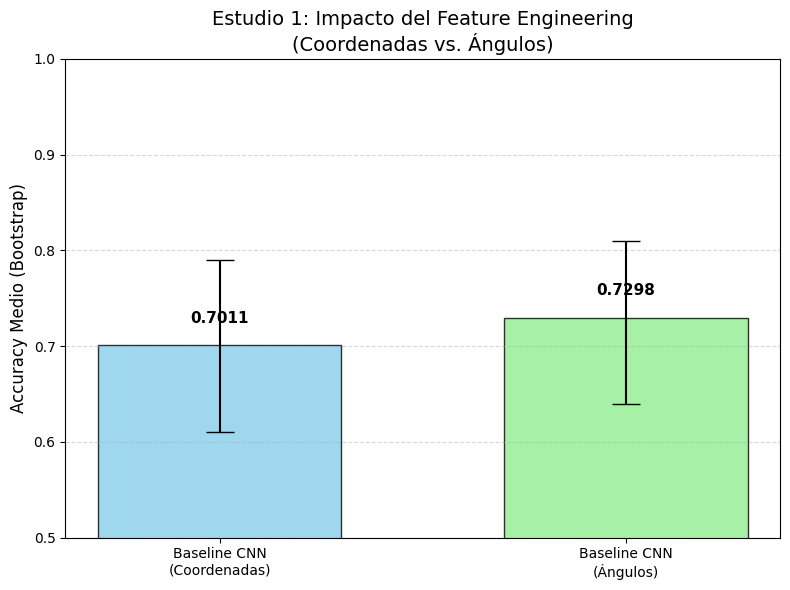

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os


# Seleccionamos solo los experimentos del Estudio 1
ids_interes = ['EXP-CNN-01', 'EXP-CNN-02'] 

study_df = df_resultados[df_resultados['ID Exp.'].isin(ids_interes)].copy()

# Asignamos nombres legibles para el eje X
nombres_legibles = {
    'EXP-CNN-01': 'Baseline CNN\n(Coordenadas)',
    'EXP-CNN-02': 'Baseline CNN\n(Ángulos)'
}
study_df['Nombre'] = study_df['ID Exp.'].map(nombres_legibles)

# 3. CALCULAR LOS ERRORES RELATIVOS
# Matplotlib necesita: [Distancia hacia abajo, Distancia hacia arriba]
study_df['err_down'] = study_df['Acc. Medio'] - study_df['IC Inf (95%)']
study_df['err_up']   = study_df['IC Sup (95%)'] - study_df['Acc. Medio']

# Preparamos la matriz de errores (2, N) que pide matplotlib
yerr = [study_df['err_down'].values, study_df['err_up'].values]

# Gráfico de barras con barras de error
plt.figure(figsize=(8, 6))

# Colores diferenciados
colors = ['skyblue', 'lightgreen']

bars = plt.bar(
    study_df['Nombre'], 
    study_df['Acc. Medio'], 
    yerr=yerr,          
    capsize=10,         
    color=colors, 
    edgecolor='black',
    alpha=0.8,
    width=0.6
)


plt.ylabel('Accuracy Medio (Bootstrap)', fontsize=12)
plt.title('Estudio 1: Impacto del Feature Engineering\n(Coordenadas vs. Ángulos)', fontsize=14)
plt.ylim(0.5, 1.0) # Ajustar zoom (si tus resultados son altos, pon 0.7 o 0.8)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadimos el valor numérico encima de las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

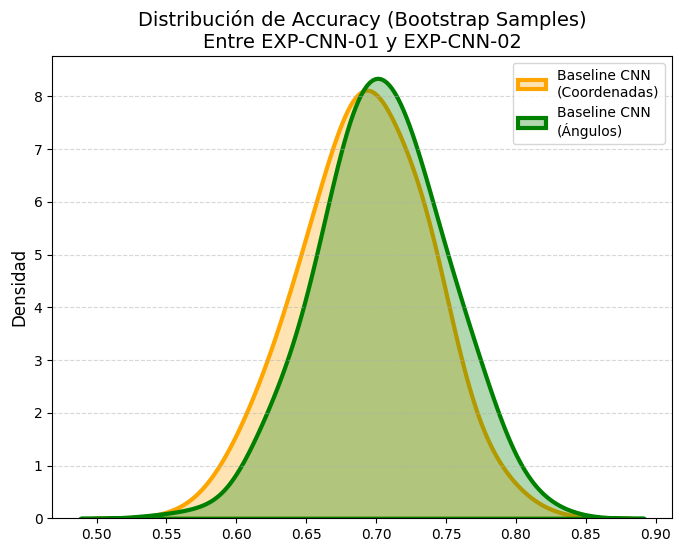

In [5]:
PATH = '../results'
FILE_NAME_CNN_01 = 'bootstrap_accuracies_exp_cnn_01.npy'
FILE_NAME_CNN_02 = 'bootstrap_accuracies_exp_cnn_02.npy'

ba_exp_cnn_01 = np.load(os.path.join(PATH, FILE_NAME_CNN_01))
ba_exp_cnn_02 = np.load(os.path.join(PATH, FILE_NAME_CNN_02))

# Dibujamos con curvas de densidad
plt.figure(figsize=(8, 6))

sns.kdeplot(ba_exp_cnn_01, color='orange', lw=3, label=nombres_legibles['EXP-CNN-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_cnn_02, color='green', lw=3, label=nombres_legibles['EXP-CNN-02'], bw_adjust=1.5, fill=True, alpha=0.3)

plt.ylabel('Densidad', fontsize=12) 
plt.title('Distribución de Accuracy (Bootstrap Samples)\nEntre EXP-CNN-01 y EXP-CNN-02', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

No se observan grandes diferencias en los resultados. Podemos establecer como punto de partida un accuracy promedio del 70 %.

## B. Exploración de Modelos Recurrentes (RNNs)
*¿Conseguimos mejorar el rendimiento del modelo con LSTMs?*

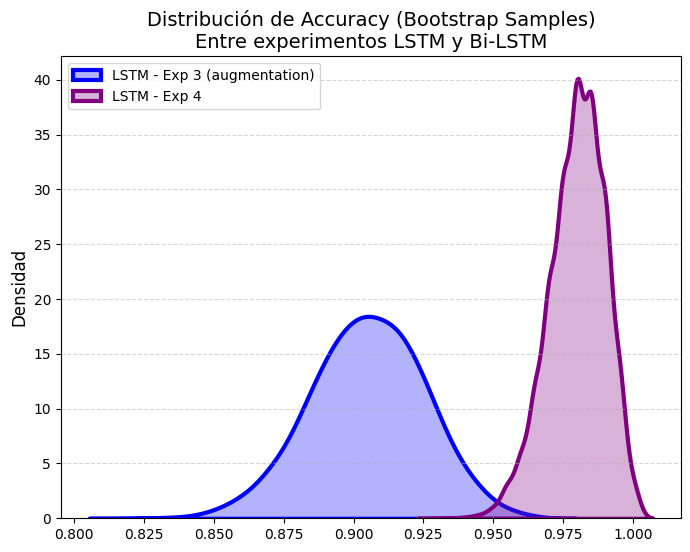

In [7]:
# En la ejecucion de los experimentos solo se han guardado la 3 y la 4. He corregido el error, falta volver a ejecutarlo para que se guarden. Maañana por la mañana lo hago.
#ba_exp_lstm_01 = np.load('../results/bootstrap_accuracies_exp_LSTM_01.npy') 
#ba_exp_lstm_02 = np.load('../results/bootstrap_accuracies_exp_LSTM_02.npy')
ba_exp_lstm_03 = np.load('../results/bootstrap_accuracies_exp_LSTM_03.npy')
ba_exp_lstm_04 = np.load('../results/bootstrap_accuracies_exp_LSTM_04.npy')
#ba_exp_bi_lstm_01 = np.load('../results/bootstrap_accuracies_exp_Bi-LSTM_01.npy')
#ba_exp_bi_lstm_02 = np.load('../results/bootstrap_accuracies_exp_Bi-LSTM_02.npy')
#ba_exp_bi_lstm_03 = np.load('../results/bootstrap_accuracies_exp_Bi-LSTM_03.npy')
#ba_exp_bi_lstm_04 = np.load('../results/bootstrap_accuracies_exp_Bi-LSTM_04.npy')

nombres_legibles_lstm = {
    'EXP-LSTM-01': 'LSTM - Exp 1 (simple)',
    'EXP-LSTM-02': 'LSTM - Exp 2 (angles)',
    'EXP-LSTM-03': 'LSTM - Exp 3 (augmentation)', 
    'EXP-LSTM-04': 'LSTM - Exp 4 (augmentation-angles)',
    'EXP-Bi-LSTM-01': 'Bi-LSTM - Exp 1 (bidirectional-simple)',
    'EXP-Bi-LSTM-02': 'Bi-LSTM - Exp 2 (bidirectional-angles)',
    'EXP-Bi-LSTM-03': 'Bi-LSTM - Exp 3 (bidirectional-augmentation)',
    'EXP-Bi-LSTM-04': 'Bi-LSTM - Exp 4 (bidirectional-augmentation-angles)'
}

# Dibujamos con curvas de densidad
plt.figure(figsize=(8, 6))

#sns.kdeplot(ba_exp_lstm_01, color='orange', lw=3, label=nombres_legibles_lstm['EXP-LSTM-01'], bw_adjust=1.5, fill=True, alpha=0.3)
#sns.kdeplot(ba_exp_lstm_02, color='green', lw=3, label=nombres_legibles_lstm['EXP-LSTM-02'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_lstm_03, color='blue', lw=3, label=nombres_legibles_lstm['EXP-LSTM-03'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_lstm_04, color='purple', lw=3, label='LSTM - Exp 4', bw_adjust=1.5, fill=True, alpha=0.3)
#sns.kdeplot(ba_exp_bi_lstm_01, color='red', lw=3, label=nombres_legibles_lstm['EXP-Bi-LSTM-01'], bw_adjust=1.5, fill=True, alpha=0.3)
#sns.kdeplot(ba_exp_bi_lstm_02, color='red', lw=3, label='Bi-LSTM - Exp 2', bw_adjust=1.5, fill=True, alpha=0.3)
#sns.kdeplot(ba_exp_bi_lstm_03, color='red', lw=3, label='Bi-LSTM - Exp 3', bw_adjust=1.5, fill=True, alpha=0.3)
#sns.kdeplot(ba_exp_bi_lstm_04, color='red', lw=3, label='Bi-LSTM - Exp 4', bw_adjust=1.5, fill=True, alpha=0.3)

plt.ylabel('Densidad', fontsize=12) 
plt.title('Distribución de Accuracy (Bootstrap Samples)\nEntre experimentos LSTM y Bi-LSTM', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Nos quedamos con el mejor experimento LSTM
best_lstm_exp = ...
best_lstm_name = ... 

# Comparamos con los baseline CNNs
# Dibujamos con curvas de densidad
plt.figure(figsize=(8, 6))

sns.kdeplot(best_lstm_exp, color='purple', lw=3, label=nombres_legibles[best_lstm_name], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_cnn_01, color='orange', lw=3, label=nombres_legibles['EXP-CNN-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(ba_exp_cnn_02, color='green', lw=3, label=nombres_legibles['EXP-CNN-02'], bw_adjust=1.5, fill=True, alpha=0.3)
plt.ylabel('Densidad', fontsize=12) 
plt.title('Distribución de Accuracy (Bootstrap Samples)\nEntre experimentos LSTM y baselines CNN', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## C. Resultados con un Modelado Espacio-Temporal Avanzado (ST-GCN)
*¿Un modelo híbrido avanzado conseguirá mejores puntuaciones que las LSTM?*

In [ ]:
ba_exp_st_gcn_01 = np.load('../results/bootstrap_accuracies_exp_st_gcn_01.npy')

nombres_legibles_st_gcn = {
    'EXP-ST-GCN-01': 'ST-GCN - Exp 1',

}

# Dibujamos con curvas de densidad
plt.figure(figsize=(8, 6))

sns.kdeplot(ba_exp_st_gcn_01, color='orange', lw=3, label=nombres_legibles_st_gcn['EXP-ST-GCN-01'], bw_adjust=1.5, fill=True, alpha=0.3)
sns.kdeplot(best_lstm_exp, color='purple', lw=3, label=nombres_legibles[best_lstm_name], bw_adjust=1.5, fill=True, alpha=0.3)

plt.ylabel('Densidad', fontsize=12) 
plt.title('Distribución de Accuracy (Bootstrap Samples)\nEntre experimentos ST-GCN y anteriores', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## D. Evaluación de Robustez (Data Augmentation)
Comparamos los modelos entrenados con datos originales y con datos augmentados.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. CONFIGURACIÓN DE PAREJAS A COMPARAR
pares_comparativa = [
    # (Etiqueta Eje X,      ID Original,   ID Aumentado)
    ('Baseline CNN (coord)',       'EXP-CNN-01',  'EXP-CNN-03'), 
    ('Baseline CNN (ángulos)',     'EXP-CNN-02',  'EXP-CNN-04'),
    ('LSTM (2 capas)',             'EXP-LSTM-02', 'EXP-LSTM-04'), 
    ('Bi-LSTM',                    'EXP-Bi-LSTM-01', 'EXP-Bi-LSTM-02'),
    ('ST-GCN',                     'EXP-ST-GCN-01', 'EXP-ST-GCN-02'),
    
]

# Listas para guardar los datos a graficar
nombres = []
means_orig, err_down_orig, err_up_orig = [], [], []
means_aug,  err_down_aug,  err_up_aug  = [], [], []

# 2. EXTRACCIÓN DE DATOS DEL DATAFRAME
for nombre, id_orig, id_aug in pares_comparativa:
    nombres.append(nombre)
    
    # --- Datos SIN Augmentation ---
    row_orig = df_resultados[df_resultados['ID Exp.'] == id_orig]
    if not row_orig.empty:
        mu = row_orig['Acc. Medio'].values[0]
        lower = row_orig['IC Inf (95%)'].values[0]
        upper = row_orig['IC Sup (95%)'].values[0]
        
        means_orig.append(mu)
        # Matplotlib pide el error relativo (distancia desde la media), no absoluto
        err_down_orig.append(mu - lower)
        err_up_orig.append(upper - mu)
    else:
        # Si no existe el dato, rellenamos con 0 para que no falle el gráfico
        means_orig.append(0); err_down_orig.append(0); err_up_orig.append(0)

    # --- Datos CON Augmentation ---
    row_aug = df_resultados[df_resultados['ID Exp.'] == id_aug]
    if not row_aug.empty:
        mu = row_aug['Acc. Medio'].values[0]
        lower = row_aug['IC Inf (95%)'].values[0]
        upper = row_aug['IC Sup (95%)'].values[0]
        
        means_aug.append(mu)
        err_down_aug.append(mu - lower)
        err_up_aug.append(upper - mu)
    else:
        means_aug.append(0); err_down_aug.append(0); err_up_aug.append(0)

# 3. PREPARACIÓN DEL GRÁFICO
x = np.arange(len(nombres))  # Posiciones en el eje X (0, 1, 2...)
width = 0.35                 # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Matplotlib requiere los errores en formato (2, N) -> [[errores_abajo], [errores_arriba]]
yerr_orig = [err_down_orig, err_up_orig]
yerr_aug  = [err_down_aug, err_up_aug]

# --- DIBUJAR BARRAS ---
# Restamos width/2 para desplazar a la izquierda y sumamos para la derecha
rects1 = ax.bar(x - width/2, means_orig, width, yerr=yerr_orig, 
                label='Sin Data Augmentation', capsize=5, 
                color='skyblue', edgecolor='black', alpha=0.9)

rects2 = ax.bar(x + width/2, means_aug, width, yerr=yerr_aug, 
                label='Con Data Augmentation', capsize=5, 
                color='salmon', edgecolor='black', alpha=0.9)

# 4. ESTÉTICA Y ETIQUETAS
ax.set_ylabel('Accuracy Medio (Bootstrap)')
ax.set_title('Impacto del Data Augmentation por Arquitectura')
ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=11)
ax.set_ylim(0.6, 1.05) # Ajustar zoom según tus datos reales
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Función auxiliar para poner etiquetas encima de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0: # Solo etiquetar si hay dato
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()